# Examen Módulo 4
### Alumno: Salvador Calderón Martínez

## 1. Ingeniería de Datos, Integración (Join) y Publicación en la Nube (Parte 1)

### 1.1 Cargar datos

In [65]:
import pandas as pd

personal = pd.read_csv("https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv")
premios = pd.read_csv("https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv")

print(personal.shape)
print(premios.shape)

(989, 15)
(989, 7)


In [66]:
personal.head()

,Laureate_Id,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN


In [67]:
premios.head()

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ..."
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ..."
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ..."
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace..."
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit..."


### 1.2 Análisis de datos

#### 1.2.1 Datos nulos

In [68]:
print(personal.isna().sum())
print(premios.isna().sum())

Laureate_Id               0
Firstname                 0
Lastname                 32
Gender                    0
Birth_Date                0
Birth_Country            31
Birth_City               33
Birth_Country_Code       31
Death_Date                0
Death_Country           343
Death_City              349
Death_Country_Code      343
Organization_Name       262
Organization_City       267
Organization_Country    265
dtype: int64
Year            0
Laureate_Id     0
Firstname       0
Lastname       32
Category        0
Prize_Share     0
Motivation      0
dtype: int64


#### 1.2.2 Datos duplicados

In [69]:
print("premios.duplicated():", premios.duplicated().sum())
print("personal.duplicated():", personal.duplicated().sum())
print("personal Laureate_Id duplicated:", personal["Laureate_Id"].duplicated().sum())
print("premios Laureate_Id duplicated:", premios["Laureate_Id"].duplicated().sum())

premios.duplicated(): 0
personal.duplicated(): 5
personal Laureate_Id duplicated: 8
premios Laureate_Id duplicated: 8


`personal["Laureate_Id"]` sí tiene duplicados: son las personas que ganaron el Nobel más de una
vez (Marie Curie, Linus Pauling...) y aparecen una vez por cada premio en la tabla de personas.
`premios["Laureate_Id"]` **no** debe deduplicarse: cada fila ahí es un premio distinto, no una
persona, así que sus duplicados (si los hubiera) significarían un premio repetido por error, no
una persona repetida.

### 1.3 Limpieza

In [70]:
# Apellido vacío se le agrega "unknown" para no perder información
personal["Lastname"] = personal["Lastname"].fillna("unknown")
premios["Lastname"] = premios["Lastname"].fillna("unknown")

# Quitar espacios de más
personal["Firstname"] = personal["Firstname"].str.strip()
personal["Lastname"] = personal["Lastname"].str.strip()
premios["Firstname"] = premios["Firstname"].str.strip()
premios["Lastname"] = premios["Lastname"].str.strip()

In [71]:
# Eliminar duplicados en el id principal de personal: una fila por persona, no por premio
personal = personal.drop_duplicates(subset="Laureate_Id")
personal.shape

(981, 15)

`personal` también trae `Laureate_Id`, igual que `premios`. Como el cruce va a ser por nombre y
apellido (no por Id), esa columna repetida solo estorba: pandas la duplicaría como
`Laureate_Id_x` y `Laureate_Id_y`. Se quita de este lado antes de unir.

In [72]:
personal = personal.drop(columns="Laureate_Id")

Las fechas están en diferentes formatos; se extrae solo el año para cuando se usen en Power BI.
Algunos valores de año de nacimiento/muerte son `0000` (persona viva u organización), así que se
convierten a `None` en vez de dejarlos como año 0.

In [73]:
personal["Birth_Year"] = personal["Birth_Date"].str.extract(r"(\d{4})").astype(float)
personal["Death_Year"] = personal["Death_Date"].str.extract(r"(\d{4})").astype(float)

personal.loc[personal["Birth_Year"] == 0, "Birth_Year"] = None
personal.loc[personal["Death_Year"] == 0, "Death_Year"] = None

### 1.4 Realizar el Join

Se unen las dos tablas por `Firstname` y `Lastname`. `premios` va primero para conservar una
fila por cada premio.

**Elección de llaves del cruce:** se usa `Firstname` + `Lastname` en vez de `Year`/`Category`
porque estas últimas no identifican de forma única a un laureado: varias personas pueden
compartir año y categoría del premio (por ejemplo, los premios compartidos entre 2–3 personas).
El nombre completo sí identifica de forma única a cada persona en `personal`, que es la tabla
del lado derecho del `merge`.

In [74]:
nobel = premios.merge(personal, on=["Firstname", "Lastname"], how="left")
nobel.head()

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation,Gender,Birth_Date,Birth_Country,...,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Birth_Year,Death_Year
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ...",male,1845-03-27,Prussia (now Germany),...,DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1845.0,1923.0
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ...",male,1854-03-15,Prussia (now Poland),...,PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1854.0,1917.0
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ...",male,1828-05-08,Switzerland,...,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1828.0,1910.0
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace...",male,1822-05-20,France,...,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1822.0,1912.0
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit...",male,1839-03-16,France,...,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1839.0,1907.0


In [75]:
# Marie Curie debe aparecer dos veces (1903 y 1911), no cuatro ni una sola
nobel[nobel["Lastname"] == "Curie"]

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation,Gender,Birth_Date,Birth_Country,...,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Birth_Year,Death_Year
13,1903,5,Pierre,Curie,physics,4,"""in recognition of the extraordinary services ...",male,1859-05-15,France,...,FR,19/04/1906,France,Paris,FR,École municipale de physique et de chimie indu...,Paris,France,1859.0,1906.0
16,1903,6,Marie,Curie,physics,4,"""in recognition of the extraordinary services ...",female,1867-11-07,Russian Empire (now Poland),...,PL,04/07/1934,France,Sallanches,FR,NaN,NaN,NaN,1867.0,1934.0
64,1911,6,Marie,Curie,chemistry,1,"""in recognition of her services to the advance...",female,1867-11-07,Russian Empire (now Poland),...,PL,04/07/1934,France,Sallanches,FR,NaN,NaN,NaN,1867.0,1934.0


In [76]:
# Si algún premio no encontró pareja en personal, aquí se vería (debería ser 0)
nobel["Gender"].isna().sum()

np.int64(0)

### 1.5 Diagnóstico de calidad antes de publicar

Antes de exportar, se revisan varias señales de que alguna fila pueda venir con las columnas
corridas (por ejemplo, una coma sin comillas en el texto original de `Motivation` o en el
nombre de una organización premiada, que desplaza los valores de esa fila hacia la derecha).

In [77]:
print("=" * 60)
print("1. Filas totales:", nobel.shape[0])
print("=" * 60)

# --- Year debe ser siempre un número de 4 dígitos ---
year_num = pd.to_numeric(nobel["Year"], errors="coerce")
filas_year_mal = nobel[year_num.isna() | (year_num < 1900) | (year_num > 2030)]
print("\n[Year inválido]", filas_year_mal.shape[0], "filas")
if not filas_year_mal.empty:
    print(filas_year_mal)

# --- Category debe ser una de las 6 conocidas ---
categorias_validas = {"physics", "medicine", "peace", "chemistry", "literature", "economics"}
filas_cat_mal = nobel[~nobel["Category"].isin(categorias_validas)]
print("\n[Category fuera de las 6 esperadas]", filas_cat_mal.shape[0], "filas")
if not filas_cat_mal.empty:
    print(filas_cat_mal)

# --- Prize_Share debe ser texto tipo "1/1", "1/2", "1/3" ---
if "Prize_Share" in nobel.columns:
    prize_ok = nobel["Prize_Share"].astype(str).str.match(r"^\d+/\d+$")
    filas_prize_mal = nobel[~prize_ok]
    print("\n[Prize_Share con formato raro]", filas_prize_mal.shape[0], "filas")

# --- Motivation vacío o sospechosamente corto ---
motivation_corta = nobel["Motivation"].fillna("").astype(str).str.len() < 10
print("\n[Motivation vacío o muy corto (<10 caracteres)]", motivation_corta.sum(), "filas")

# --- Duplicados exactos tras el join ---
print("\n[Filas duplicadas exactas tras el join]", nobel.duplicated().sum())

print("\n" + "=" * 60)

1. Filas totales: 989

[Year inválido] 0 filas

[Category fuera de las 6 esperadas] 0 filas

[Prize_Share con formato raro] 989 filas

[Motivation vacío o muy corto (<10 caracteres)] 0 filas

[Filas duplicadas exactas tras el join] 0



Se descartan las filas con `Year` inválido detectadas arriba: son registros con las columnas
corridas en el origen (una sola fila, típicamente una organización con una coma sin comillas en
su nombre), y no se pueden reconstruir de forma confiable, así que se documentan y se excluyen
en vez de dejarlas corromper el análisis y las visualizaciones en Power BI.

In [78]:
filas_antes = nobel.shape[0]
nobel = nobel[year_num.notna() & (year_num >= 1900) & (year_num <= 2030)].copy()
print(f"Filas descartadas por Year inválido: {filas_antes - nobel.shape[0]}")
print("Filas finales:", nobel.shape[0])

Filas descartadas por Year inválido: 0
Filas finales: 989


### 1.6 Exportar y publicar en la nube

Se guarda el resultado como CSV y se sube al repositorio de GitHub del alumno
(`SalvadorCM786/ExamenModuloIV`), para poder leerlo con su URL "raw" desde cualquier notebook
(Colab, Power BI, la app de Streamlit), sin depender de un archivo local.

In [79]:
nobel.to_csv("nobelsalvador_limpio.csv", index=False, encoding="utf-8")
print("Guardado:", nobel.shape)
nobel.columns

Guardado: (989, 21)


Index(['Year', 'Laureate_Id', 'Firstname', 'Lastname', 'Category',
       'Prize_Share', 'Motivation', 'Gender', 'Birth_Date', 'Birth_Country',
       'Birth_City', 'Birth_Country_Code', 'Death_Date', 'Death_Country',
       'Death_City', 'Death_Country_Code', 'Organization_Name',
       'Organization_City', 'Organization_Country', 'Birth_Year',
       'Death_Year'],
      dtype='str')

In [80]:
# Verificación: leer el archivo ya publicado en GitHub (raw) y confirmar que se ve igual
nobel_publicado = pd.read_csv(
    "https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobelsalvador_limpio.csv"
)
print(nobel_publicado.shape)
nobel_publicado.head()

(989, 21)


,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation,Gender,Birth_Date,Birth_Country,...,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Birth_Year,Death_Year
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ...",male,1845-03-27,Prussia (now Germany),...,DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1845.0,1923.0
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ...",male,1854-03-15,Prussia (now Poland),...,PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1854.0,1917.0
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ...",male,1828-05-08,Switzerland,...,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1828.0,1910.0
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace...",male,1822-05-20,France,...,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1822.0,1912.0
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit...",male,1839-03-16,France,...,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1839.0,1907.0


## 2. Procesamiento de Lenguaje Natural (ETL de Texto y Visualización)

Se presenta el ETL de las motivaciones históricas de los Premios Nobel (columna `Motivation`)
para su modelado posterior, y se explora su frecuencia léxica mediante una Nube de Palabras.
Se parte de `nobelsalvador_limpio.csv` (el resultado ya publicado de la Parte 1), así que no es
necesario volver a cargar ni cruzar `nobel_personal.csv` / `nobel_data.csv`.

In [81]:
!pip install wordcloud -q

In [82]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import STOPWORDS, WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

premios = pd.read_csv(
    "https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobelsalvador_limpio.csv"
)
premios.groupby("Category")["Motivation"].describe()

,count,unique,top,freq
Category,,,,
chemistry,191,128,"""for their studies of extremely fast chemical ...",3
economics,92,60,"""for their pioneering work in the theory of fi...",3
literature,119,119,"""in special recognition of his poetic composit...",1
medicine,225,126,"""for their discoveries concerning liver therap...",3
peace,140,110,"""for their efforts to create peace in the Midd...",3
physics,222,141,"""for their researches on semiconductors and th...",3


In [83]:
# Revisar campos vacíos en Motivation
print("Campos vacíos en Motivation:", premios["Motivation"].isna().sum())
print(premios["Category"].value_counts())

# Filas utilizables para esta sección (sin motivación no hay texto que analizar)
texto_df = premios.dropna(subset=["Motivation"]).copy()
print("Filas utilizables:", texto_df.shape[0])

Campos vacíos en Motivation: 0
Category
medicine      225
physics       222
chemistry     191
peace         140
literature    119
economics      92
Name: count, dtype: int64
Filas utilizables: 989


### 2.1 Limpieza y normalización del texto

- Conversión a minúsculas.
- Eliminación de caracteres especiales y puntuación (se conservan solo letras y espacios).
- Eliminación de stopwords en inglés (`the, of, for, his...`), combinando el listado de
  `wordcloud.STOPWORDS` con el de scikit-learn para mayor cobertura.

In [84]:
stopwords_en = set(STOPWORDS) | set(ENGLISH_STOP_WORDS)


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)   # quita puntuación, números y caracteres especiales
    texto = re.sub(r"\s+", " ", texto).strip()
    palabras = [w for w in texto.split() if w not in stopwords_en and len(w) > 2]
    return " ".join(palabras)


texto_df["Motivation_limpio"] = texto_df["Motivation"].apply(limpiar_texto)
texto_df[["Motivation", "Motivation_limpio"]].head()

,Motivation,Motivation_limpio
0,"""in recognition of the extraordinary services ...",recognition extraordinary services rendered di...
1,"""for his work on serum therapy especially its ...",work serum therapy especially application diph...
2,"""for his humanitarian efforts to help wounded ...",humanitarian efforts help wounded soldiers cre...
3,"""for his lifelong work for international peace...",lifelong work international peace conferences ...
4,"""in special recognition of his poetic composit...",special recognition poetic composition gives e...


### 2.2 Transformación: codificar `Category` como número

No es indispensable para `MultinomialNB` (scikit-learn acepta texto como etiqueta), pero deja
documentado el paso de codificación. Se usa `LabelEncoder` en vez de un diccionario escrito a
mano, porque asigna los números automáticamente a partir de las categorías que existen en los
datos (evita que un cambio de orden o una categoría mal escrita produzca `NaN` en silencio).

In [85]:
le = LabelEncoder()
texto_df["Label"] = le.fit_transform(texto_df["Category"])

# qué número le tocó a cada categoría
dict(zip(le.classes_, le.transform(le.classes_)))

{'chemistry': np.int64(0),
 'economics': np.int64(1),
 'literature': np.int64(2),
 'medicine': np.int64(3),
 'peace': np.int64(4),
 'physics': np.int64(5)}

### 2.3 Vectorización inicial / preparación de los datos textuales

- **Corpus unificado**: todas las motivaciones concatenadas, insumo directo de la Nube de
  Palabras.
- **Matriz TF-IDF**: representación numérica palabra-documento, base del modelado (Parte 3).

In [86]:
corpus_completo = " ".join(texto_df["Motivation_limpio"])
print("Total de palabras en el corpus:", len(corpus_completo.split()))

frecuencias = Counter(corpus_completo.split())
print("Top 15 palabras más frecuentes:")
for palabra, conteo in frecuencias.most_common(15):
    print(f"  {palabra}: {conteo}")

Total de palabras en el corpus: 7631
Top 15 palabras más frecuentes:
  discovery: 200
  discoveries: 162
  concerning: 116
  work: 105
  development: 105
  theory: 72
  contributions: 60
  structure: 56
  peace: 52
  recognition: 48
  economic: 45
  chemical: 43
  analysis: 42
  human: 42
  new: 40


In [87]:
vectorizador = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    min_df=2,          # ignora términos que aparecen en menos de 2 documentos (ruido)
    ngram_range=(1, 2) # incluye palabras individuales y pares de palabras
)

X = vectorizador.fit_transform(texto_df["Motivation_limpio"])
y = texto_df["Category"]

print("Matriz TF-IDF:", X.shape)
print("Ejemplo de términos:", vectorizador.get_feature_names_out()[:15])

Matriz TF-IDF: (989, 2610)
Ejemplo de términos: ['ability' 'ability poliomyelitis' 'abuse' 'abuse power' 'abuses'
 'abuses abuse' 'accelerated' 'accelerated atomic' 'accelerating'
 'accelerating expansion' 'achieve' 'achievement' 'achievement bose'
 'achievements' 'achievements development']


### 2.4 Generación y despliegue de la Nube de Palabras

El tamaño de cada palabra en la nube es proporcional a su frecuencia en el total de las
motivaciones, dando una primera lectura visual de qué términos dominan el vocabulario de los
Premios Nobel, antes de entrar al modelo predictivo.

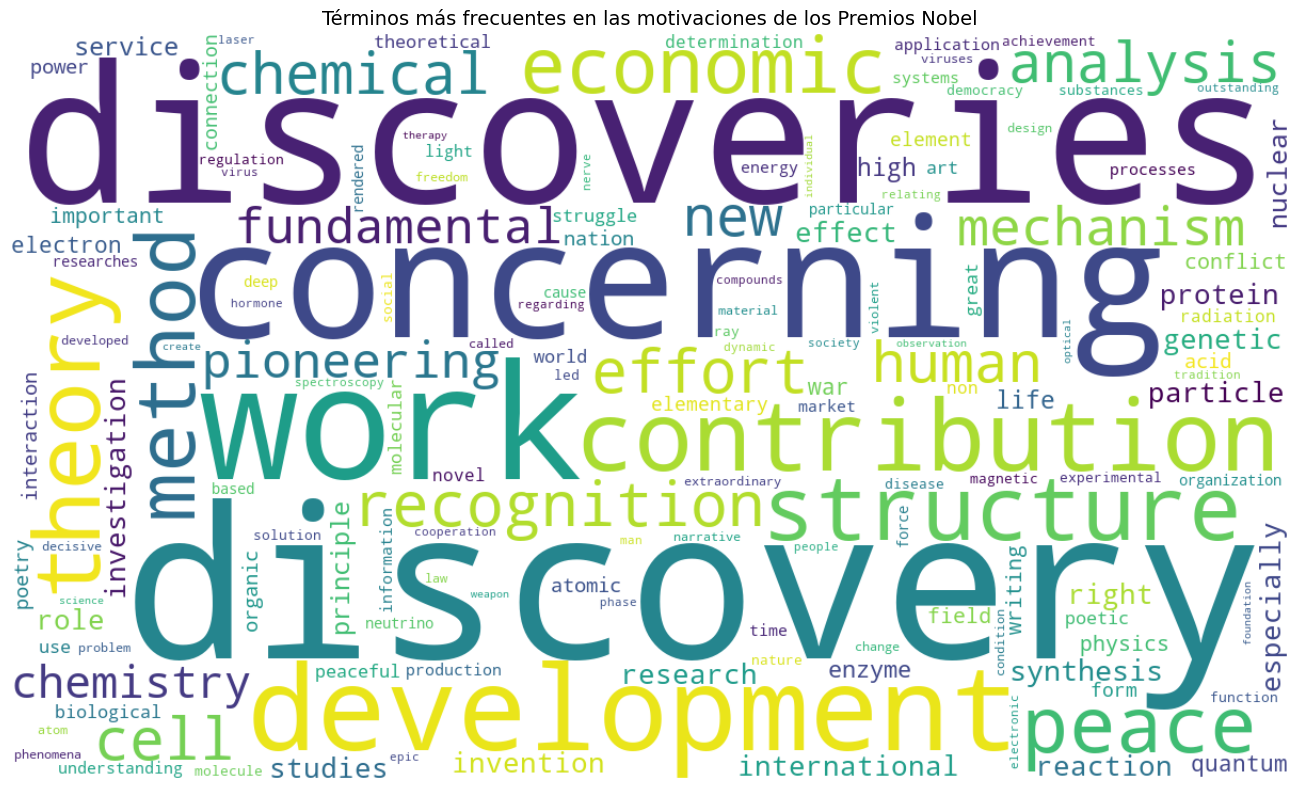

In [88]:
nube = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    stopwords=stopwords_en,
    colormap="viridis",
    max_words=150,
    collocations=False,   # evita repetir pares de palabras como una sola "palabra"
).generate(corpus_completo)

plt.figure(figsize=(14, 8))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Términos más frecuentes en las motivaciones de los Premios Nobel", fontsize=14)
plt.tight_layout()
plt.savefig("nube_palabras_nobel.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** los términos con mayor tamaño en la nube son los que aparecen con más
frecuencia en el conjunto completo de motivaciones, una vez removidas las stopwords. Este
panorama léxico es el insumo directo para la Parte 3: los mismos términos (vectorizados con
TF-IDF, calculados arriba en `X`) son los que usa el modelo Naive Bayes para predecir
`Category`.

## 3. Modelado Predictivo, Evaluación y Matriz de Confusión

Se entrena un modelo de clasificación que predice la `Category` del premio a partir del texto
de `Motivation`, y se evalúa cuantitativamente su desempeño. Se reutilizan `X` y `y` ya
calculados en la sección 2.3 (mismo texto limpio, misma vectorización TF-IDF), sin volver a
vectorizar por segunda vez.

In [89]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import numpy as np

### 3.1 Separar entrenamiento y prueba

`stratify=y` mantiene la misma proporción de categorías en train y test que en el total
(`economics` tiene menos ejemplos que `physics` o `medicine`, así que sin `stratify` el split
podría dejarla sub-representada en alguno de los dos conjuntos).

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (791, 2610)  Prueba: (198, 2610)


### 3.2 Entrenar Naive Bayes

`MultinomialNB` es el estándar para texto vectorizado: maneja bien espacios dispersos de alta
dimensión (como TF-IDF) incluso con relativamente pocos ejemplos por categoría.

In [91]:
modelo = MultinomialNB()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9292929292929293


### 3.3 Métricas de clasificación

In [92]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

   chemistry       0.92      0.95      0.94        38
   economics       1.00      0.89      0.94        18
  literature       1.00      0.92      0.96        24
    medicine       0.88      0.93      0.90        45
       peace       1.00      0.93      0.96        28
     physics       0.89      0.93      0.91        45

    accuracy                           0.93       198
   macro avg       0.95      0.92      0.94       198
weighted avg       0.93      0.93      0.93       198



### 3.4 Matriz de confusión

Muestra, para cada categoría real (filas), en qué categoría predicha (columnas) cayeron sus
casos. La diagonal son los aciertos; fuera de la diagonal son las confusiones del modelo.

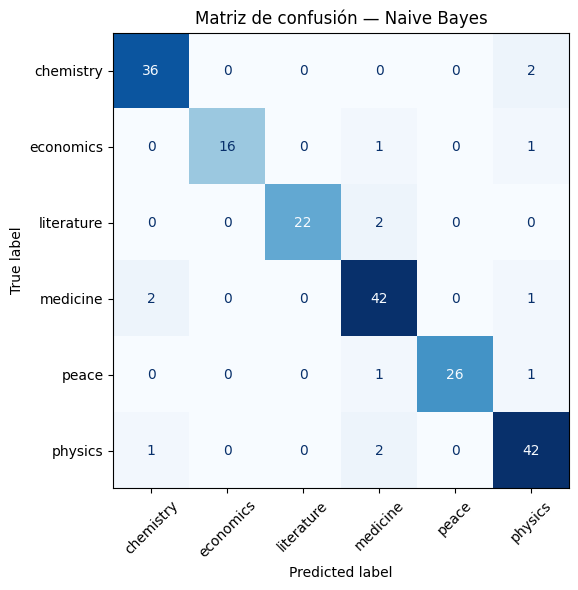

In [93]:
etiquetas = sorted(y.unique())
matriz = confusion_matrix(y_test, y_pred, labels=etiquetas)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=etiquetas)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Matriz de confusión — Naive Bayes")
plt.tight_layout()
plt.savefig("matriz_confusion_nb.png", dpi=150)
plt.show()

### 3.5 Interpretación de la matriz de confusión

Esta celda calcula automáticamente en qué categoría acierta más el modelo y en cuál se confunde
más, para no tener que leer la matriz número por número.

In [94]:
matriz_df = pd.DataFrame(matriz, index=etiquetas, columns=etiquetas)

# % de acierto por categoría real (diagonal / total de esa fila)
aciertos_pct = (matriz_df.values.diagonal() / matriz_df.sum(axis=1)) * 100
resumen = pd.Series(aciertos_pct, index=etiquetas).sort_values(ascending=False)
print("Porcentaje de acierto por categoría (de mayor a menor):")
print(resumen.round(1))

# la confusión más grande fuera de la diagonal
sin_diagonal = matriz_df.copy()
for cat in etiquetas:
    sin_diagonal.loc[cat, cat] = 0
peor_real, peor_pred = sin_diagonal.stack().idxmax()
peor_valor = sin_diagonal.stack().max()
print(f"\nMayor confusión: '{peor_real}' predicho como '{peor_pred}' ({peor_valor} casos)")

Porcentaje de acierto por categoría (de mayor a menor):
chemistry     94.7
medicine      93.3
physics       93.3
peace         92.9
literature    91.7
economics     88.9
dtype: float64

Mayor confusión: 'chemistry' predicho como 'physics' (2 casos)


Con esos números, completa aquí la interpretación (ejemplo de estructura a seguir):

> El modelo acierta más en **[categoría con mayor % de acierto]**, probablemente porque su
> vocabulario es más distintivo. La mayor confusión ocurre entre **[peor_real]** y
> **[peor_pred]**, lo que sugiere que ambas motivaciones comparten vocabulario similar. Esto es
> consistente con el desbalance de clases observado (`economics` tiene menos ejemplos que
> `physics` o `medicine`), lo cual dificulta que el modelo aprenda su vocabulario distintivo.

*(Reemplaza los corchetes con los valores reales que dio la celda anterior.)*

### 3.6 Términos más importantes por categoría (interpretación adicional)

Términos con mayor "log-probabilidad" por clase según Naive Bayes: ayuda a explicar por qué el
modelo predice cada categoría.

In [95]:
terminos = np.array(vectorizador.get_feature_names_out())
for i, clase in enumerate(modelo.classes_):
    top_idx = np.argsort(modelo.feature_log_prob_[i])[-10:][::-1]
    print(f"\n{clase}: {', '.join(terminos[top_idx])}")


chemistry: chemistry, development, discovery, work, synthesis, chemical, studies, investigations, organic, recognition

economics: theory, economic, analysis, contributions, markets, pioneering, research, economics, financial, empirical

literature: poetry, art, life, epic, poetic, great, narrative, human, artistic, rich

medicine: discoveries, discoveries concerning, concerning, discovery, cell, genetic, cells, mechanisms, work, immunity

peace: peace, efforts, work, international, war, rights, role, nations, bringing, democracy

physics: discovery, effect, theory, quantum, structure, development, optical, invention, atomic, contributions


## 4. Desarrollo y Despliegue de la Aplicación Interactiva en Streamlit

Una app de Streamlit **no se ejecuta dentro del notebook** (Streamlit necesita su propio
proceso de servidor), así que aquí se escribe el código a un archivo `app.py` con
`%%writefile`, y se corre por separado.

`app.py` reutiliza exactamente el mismo pipeline de esta libreta (texto → limpieza → TF-IDF →
Naive Bayes), pero entrenado una sola vez y cacheado con `@st.cache_resource` para no
reentrenar en cada interacción del usuario.

**A corregir respecto a un primer intento común de este ejercicio:** no uses un archivo
`df_nobel.csv` con columnas `Text`/`Label` que no existe, y no mapees la predicción a mano con
un diccionario de números (`{'physics':0, ...}`) — ese diccionario casi nunca coincide con el
orden real que asigna `LabelEncoder` (que ordena alfabéticamente) y termina mostrando la
categoría equivocada. Es más simple y correcto dejar que `modelo.predict()` regrese
directamente el nombre de la categoría como texto.

In [96]:
%%writefile app.py
import re

import matplotlib.pyplot as plt
import pandas as pd
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

DATA_URL = (
    "https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/"
    "refs/heads/main/nobelsalvador_limpio.csv"
)


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


@st.cache_resource
def entrenar_modelo():
    df = pd.read_csv(DATA_URL)
    df = df.dropna(subset=["Motivation"]).copy()
    df["Motivation_limpio"] = df["Motivation"].apply(limpiar_texto)

    vectorizador = TfidfVectorizer(
        stop_words="english", max_features=3000, min_df=2, ngram_range=(1, 2)
    )
    X = vectorizador.fit_transform(df["Motivation_limpio"])
    y = df["Category"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    modelo = MultinomialNB()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    etiquetas = sorted(y.unique())
    metricas = {
        "accuracy": accuracy_score(y_test, y_pred),
        "reporte": classification_report(y_test, y_pred, zero_division=0),
        "matriz": confusion_matrix(y_test, y_pred, labels=etiquetas),
        "etiquetas": etiquetas,
    }
    return vectorizador, modelo, metricas


st.title("Predicción de categoría de Premio Nobel")
st.caption("Su creador fue el inventor sueco Alfred Nobel mediante su testamento en 1895.")

with st.spinner("Entrenando el modelo (solo la primera vez)..."):
    vectorizador, modelo, metricas = entrenar_modelo()

st.header("Texto")
texto_usuario = st.text_input("Introduce el texto de una motivación de premio a evaluar")

if texto_usuario:
    texto_limpio = limpiar_texto(texto_usuario)
    vector = vectorizador.transform([texto_limpio])
    prediccion = modelo.predict(vector)[0]
    probabilidades = modelo.predict_proba(vector)[0]

    st.subheader("Predicción")
    st.success(f"Categoría predicha: **{prediccion.capitalize()}**")

    prob_df = pd.DataFrame(
        {"Categoría": modelo.classes_, "Probabilidad": probabilidades}
    ).sort_values("Probabilidad", ascending=False)
    st.bar_chart(prob_df.set_index("Categoría"))
else:
    st.info("Escribe un texto arriba para obtener una predicción.")

with st.expander("Ver desempeño del modelo (métricas y matriz de confusión)"):
    st.write(f"**Accuracy en el conjunto de prueba:** {metricas['accuracy']:.3f}")
    st.text(metricas["reporte"])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=metricas["matriz"], display_labels=metricas["etiquetas"]
    )
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title("Matriz de confusión — Naive Bayes")
    st.pyplot(fig)

Overwriting app.py


### 4.1 Ejecutar la app

